In [1]:
import concurrent.futures
import glob
import gzip

import numpy as np
import pandas as pd


def process_base_file(base_file, mito_length):
    cur_base_data = pd.read_csv(gzip.open(base_file), header=None)

    # gather coverage for forward strand
    fwd_base_df = cur_base_data[[0, 1, 2]].pivot_table(index=1, columns=0)
    fwd_base_df.columns = [x[1] for x in fwd_base_df.columns.values]  # flatten weird multiindex after pivot
    fwd_base_df.index.name = None
    all_columns = list(range(1, mito_length + 1))
    fwd_base_df = fwd_base_df.reindex(columns=all_columns, fill_value=0)
    fwd_base_df = fwd_base_df.fillna(0).sort_index(axis=1)  # assume all nan are true zeroes

    # gather coverage for reverse strand
    rev_base_df = cur_base_data[[0, 1, 3]].pivot_table(index=1, columns=0)
    rev_base_df.columns = [x[1] for x in rev_base_df.columns.values]
    rev_base_df.index.name = None
    rev_base_df = rev_base_df.reindex(columns=all_columns, fill_value=0)
    rev_base_df = rev_base_df.fillna(0).sort_index(axis=1)

    return fwd_base_df, rev_base_df


def load_mgatk_output(output_dir, mito_length):
    # assuming mgatk output naming convention
    base_files = [glob.glob(output_dir + "*.{}.txt.gz".format(nt))[0] for nt in "ATCG"]

    base_coverage_dict = {}
    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = {executor.submit(process_base_file, base_file, mito_length): nt for base_file, nt in zip(base_files, "ATCG")}
        for future in concurrent.futures.as_completed(futures):
            nt = futures[future]
            base_coverage_dict[nt] = future.result()

    return base_coverage_dict


def gather_possible_variants(base_coverage_dict, reference_file):
    # sum across cells and strands for each base and position
    aggregated_genotype = pd.DataFrame(np.zeros((4, mito_length)), index=list("ATCG"), columns=np.arange(1, mito_length + 1))
    for nt in base_coverage_dict:
        # sum across cells for each strand separately
        fwd_base_df, rev_base_df = base_coverage_dict[nt]
        fwd_base_sum, rev_base_sum = fwd_base_df.sum(), rev_base_df.sum()

        # sequencing artifact if a base/position is only nonzero for one strand across cells, ignore them
        masking = ~((fwd_base_sum > 0) & (rev_base_sum > 0))  # True if position not >0 for both strands
        fwd_base_sum[masking], rev_base_sum[masking] = 0, 0

        # sum across strands
        aggregated_genotype.loc[nt, :] = fwd_base_sum + rev_base_sum

    # make a reference set of tuples (pos, ref_base)
    ref_set = [x.strip().split() for x in open(reference_file, "r").readlines()]
    ref_N_positions = [int(x[0]) for x in ref_set if x[1].upper() not in letters]
    ref_set = {(int(x[0]), x[1].upper()) for x in ref_set if x[1].upper() in letters}
    ref_dict = dict(ref_set)

    # make an observed set of tuples which are nonzero
    non_zero_idx = np.where(aggregated_genotype > 0)
    non_zero_bases = [letters[i] for i in non_zero_idx[0]]
    non_zero_pos = [int(i + 1) for i in non_zero_idx[1]]
    observed_set = list(zip(non_zero_pos, non_zero_bases))
    observed_set = {x for x in observed_set if x[0] not in ref_N_positions}  # disregard positions in ref with N

    # take difference between observed and reference
    variant_set = observed_set - ref_set
    variants = sorted([(x[0], ref_dict[x[0]], x[1]) for x in list(variant_set)], key=lambda x: x[0])  # (pos, ref base, obs base)

    return variants


In [2]:
# sys.argv[1]
MGATK_OUT_DIR = "/home/liuc9/github/scMOCHA/06-bigdata/GSE226602/cromwell-executions/scMOCHABatch/192a6bdb-b835-4f39-a21d-9423f9c8165d/call-scMOCHA/shard-13/sub.scMOCHA/c3913f7f-efd1-4d72-9615-2463d684f359/call-call_mt_variants/execution/cell/final/"
sample_prefix = "cell"  # sys.argv[2]
mito_length = 16569  # int(sys.argv[3])  # 16569
low_coverage_threshold = 10  # int(sys.argv[4])  # 10
mito_genome = "MT"  # sys.argv[5]  # chrM

In [3]:
letters = list("ATCG")

base_coverage_dict = load_mgatk_output(MGATK_OUT_DIR, mito_length)


In [4]:
cell_barcodes = base_coverage_dict["A"][0].index


In [5]:
# total coverage per position per cell
total_coverage = pd.DataFrame(np.zeros((len(cell_barcodes), mito_length)), index=cell_barcodes, columns=np.arange(1, mito_length + 1))
for nt in base_coverage_dict:
    total_coverage += base_coverage_dict[nt][0]
    total_coverage += base_coverage_dict[nt][1]

In [6]:
total_coverage.shape

(7044, 16569)

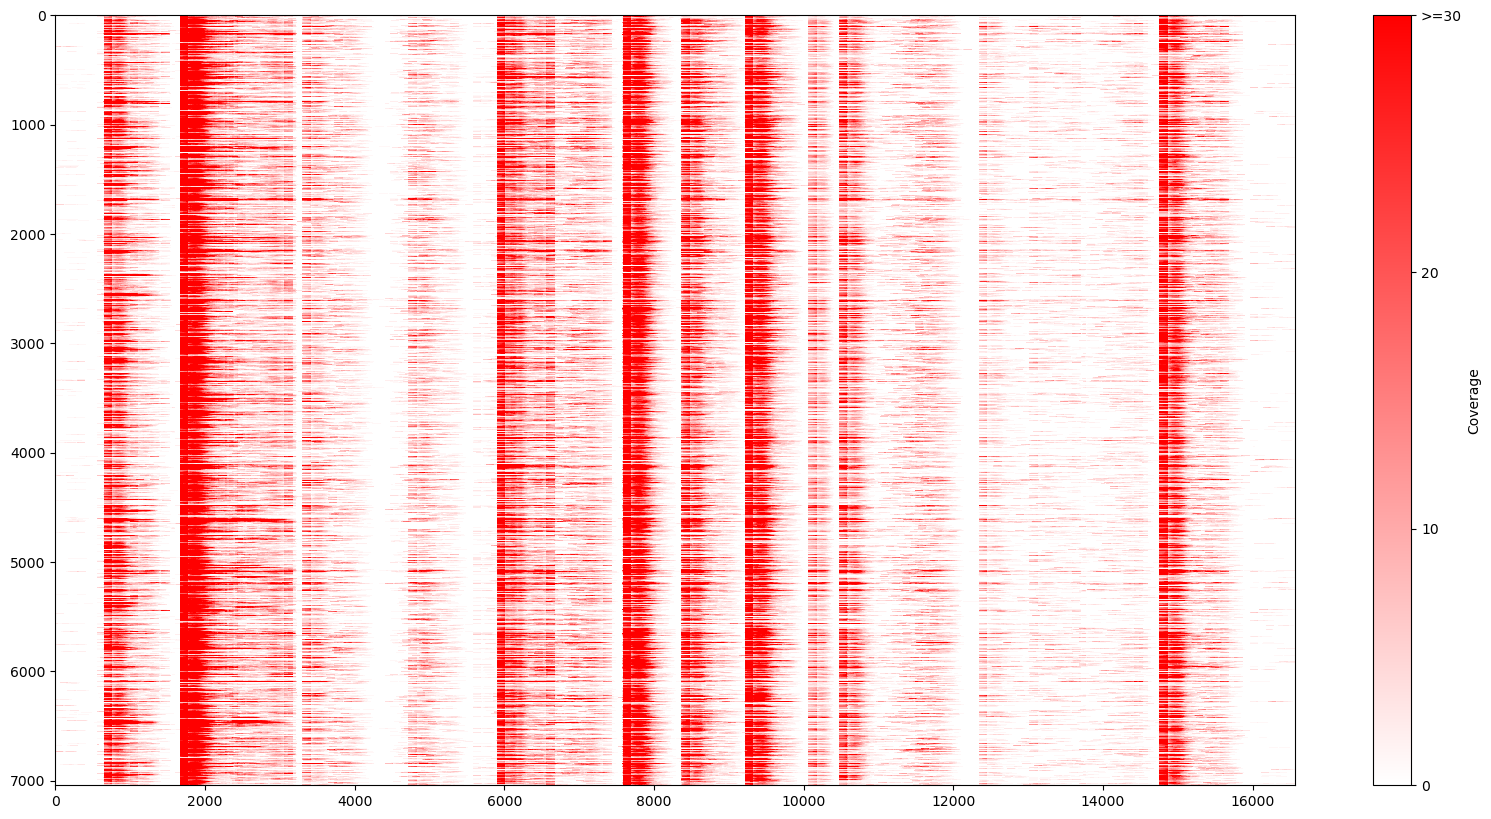

In [7]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Create a custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["white", "red"])

total_coverage_clipped = total_coverage.copy()
total_coverage_clipped[total_coverage_clipped > 30] = 30

plt.figure(figsize=(20, 10))
plt.imshow(total_coverage_clipped, aspect="auto", cmap=cmap, interpolation="nearest")
cbar = plt.colorbar(label="Coverage")
cbar.set_ticks([0, 10, 20, 30])
cbar.set_ticklabels(["0", "10", "20", ">=30"])
plt.show()

In [8]:
# Calculate mean coverage for each cell barcode
mean_coverage_per_cell = total_coverage.mean(axis=1)


In [9]:
total_coverage.index[mean_coverage_per_cell > low_coverage_threshold]

Index(['AAACCTGCATCCCATC-1', 'AAACCTGTCCGGCACA-1', 'AAACGGGGTACCCAAT-1',
       'AAACGGGGTGAAATCA-1', 'AAACGGGTCATTTGGG-1', 'AAAGATGAGCTGATAA-1',
       'AAAGATGGTCGGATCC-1', 'AAAGTAGAGAAGGGTA-1', 'AAAGTAGAGCCAACAG-1',
       'AAAGTAGCACGGTAAG-1',
       ...
       'TTTGGTTCAAGTTGTC-1', 'TTTGGTTCACGAGGTA-1', 'TTTGGTTCATATGAGA-1',
       'TTTGGTTGTTCCCTTG-1', 'TTTGGTTTCCGTCATC-1', 'TTTGTCAAGCTCCCAG-1',
       'TTTGTCACATCGGTTA-1', 'TTTGTCACATTCACTT-1', 'TTTGTCAGTTAAAGAC-1',
       'TTTGTCATCTAACTTC-1'],
      dtype='object', length=1785)

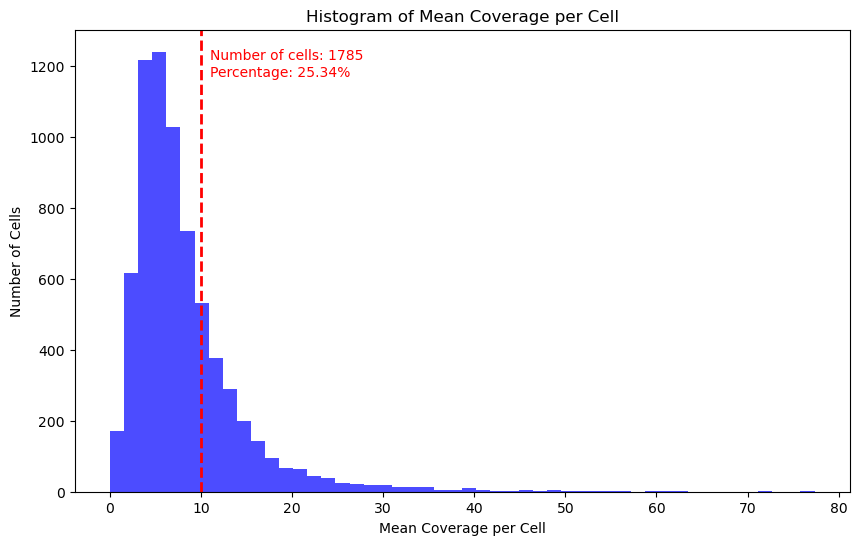

Number of cells with mean coverage greater than 10: 1785
Percentage of cells with mean coverage greater than 10: 25.34%


In [10]:
# Plot histogram of mean coverage per cell
plt.figure(figsize=(10, 6))
plt.hist(mean_coverage_per_cell, bins=50, color="blue", alpha=0.7)
plt.axvline(low_coverage_threshold, color="red", linestyle="dashed", linewidth=2)
plt.xlabel("Mean Coverage per Cell")
plt.ylabel("Number of Cells")
plt.title("Histogram of Mean Coverage per Cell")

# Calculate the percentage and number of cells greater than low_coverage_threshold
num_cells_above_threshold = (mean_coverage_per_cell > low_coverage_threshold).sum()
percentage_above_threshold = (num_cells_above_threshold / len(mean_coverage_per_cell)) * 100

# Add text to the figure
plt.text(low_coverage_threshold + 1, plt.ylim()[1] * 0.9, f"Number of cells: {num_cells_above_threshold}\nPercentage: {percentage_above_threshold:.2f}%", color="red")

plt.show()

print(f"Number of cells with mean coverage greater than {low_coverage_threshold}: {num_cells_above_threshold}")
print(f"Percentage of cells with mean coverage greater than {low_coverage_threshold}: {percentage_above_threshold:.2f}%")

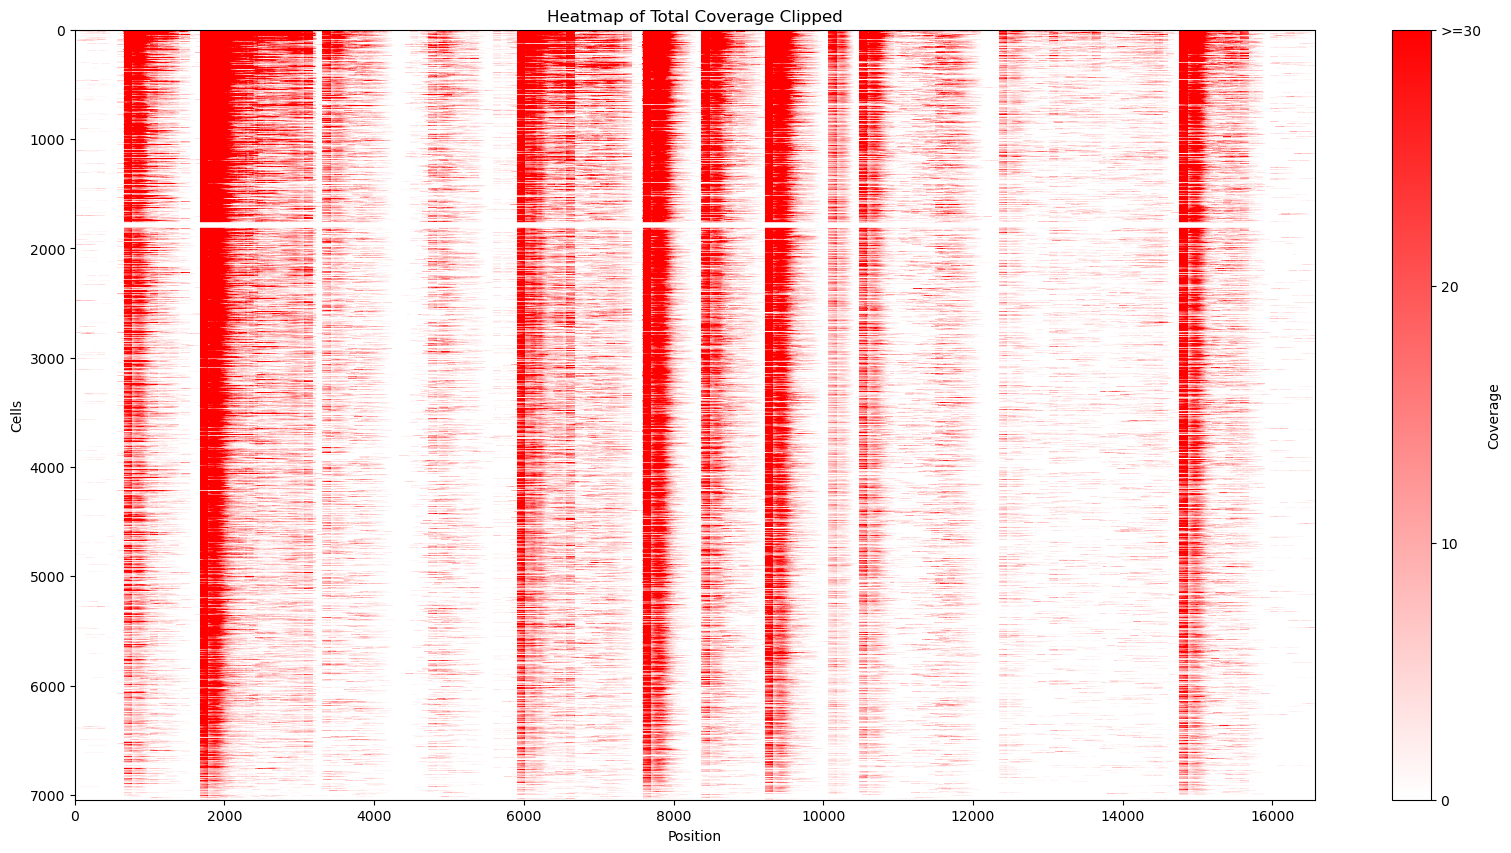

In [11]:
# Sort the cells based on mean coverage in descending order
sorted_cells = total_coverage_clipped.loc[mean_coverage_per_cell.sort_values(ascending=False).index]

# Create a mask for cells with mean coverage greater than the threshold
high_coverage_mask = mean_coverage_per_cell.sort_values(ascending=False) > low_coverage_threshold

# Plot heatmap
plt.figure(figsize=(20, 10))
plt.imshow(sorted_cells, aspect="auto", cmap=cmap, interpolation="nearest")

# Add a white line to separate high coverage cells
plt.axhline(y=high_coverage_mask.sum() - 0.5, color="white", linewidth=4)

cbar = plt.colorbar(label="Coverage")
cbar.set_ticks([0, 10, 20, 30])
cbar.set_ticklabels(["0", "10", "20", ">=30"])
plt.xlabel("Position")
plt.ylabel("Cells")
plt.title("Heatmap of Total Coverage Clipped")
plt.show()

In [ ]:
# exclude low coverage cells from variant calling
# cell_barcodes = total_coverage.index[total_coverage.mean(axis=1) > low_coverage_threshold]


In [12]:
for nt in base_coverage_dict:
    base_coverage_dict[nt] = (base_coverage_dict[nt][0].loc[cell_barcodes, :], base_coverage_dict[nt][1].loc[cell_barcodes, :])
total_coverage = total_coverage.loc[cell_barcodes, :]

In [13]:
total_coverage.shape

(7044, 16569)

In [14]:
# call potential variants
variants = gather_possible_variants(base_coverage_dict, MGATK_OUT_DIR + mito_genome + "_refAllele.txt")
variant_names = ["{}{}>{}".format(x[0], x[1], x[2]) for x in variants]

In [15]:
# build two <cell by variant tables>, one for each strand
total_coverage_variant_df = []
fwd_cell_variant_df, rev_cell_variant_df = [], []
for i, var in enumerate(variants):
    var_name = variant_names[i]
    pos, base = var[0], var[2]
    total_coverage_variant_df.append(total_coverage[pos])
    fwd_cell_variant_df.append(base_coverage_dict[base][0][pos].values)
    rev_cell_variant_df.append(base_coverage_dict[base][1][pos].values)
total_coverage_variant_df = pd.DataFrame(np.array(total_coverage_variant_df).T, index=cell_barcodes, columns=variant_names)
fwd_cell_variant_df = pd.DataFrame(np.array(fwd_cell_variant_df).T, index=cell_barcodes, columns=variant_names)
rev_cell_variant_df = pd.DataFrame(np.array(rev_cell_variant_df).T, index=cell_barcodes, columns=variant_names)
all_cell_variant_df = fwd_cell_variant_df + rev_cell_variant_df

In [16]:
# heteroplasmic ratio
heteroplasmic_df = all_cell_variant_df / total_coverage_variant_df

In [17]:
# strand correlation
mask_idx = (fwd_cell_variant_df + rev_cell_variant_df) == 0  # set 0 on both strands to nan to exclude from correlation calculation
fwd_cell_variant_df[mask_idx] = np.nan
rev_cell_variant_df[mask_idx] = np.nan


In [18]:
fwd_cell_variant_df.shape, rev_cell_variant_df.shape, all_cell_variant_df.shape, heteroplasmic_df.shape

((7044, 24005), (7044, 24005), (7044, 24005), (7044, 24005))

In [ ]:
fwd_cell_variant_df


In [19]:
variant_strand_corr = fwd_cell_variant_df.corrwith(rev_cell_variant_df).round(3)


In [20]:
# vmr
variant_mean = all_cell_variant_df.sum() / total_coverage_variant_df.sum()
variant_var = heteroplasmic_df.var()
variant_vmr = variant_var / (variant_mean + 0.00000000001)

In [21]:
# compute other summary stats

"""
Compute various summary statistics for genetic variants.

Summary statistics include:
- variant_positon: List of positions of the variants.
- variant_nucleotide: List of nucleotide changes in the format "ref>alt".
- variant_n_cells_conf_detected: Number of cells where the variant is confidently detected based on forward and reverse read counts (both >= 2) and a low coverage threshold.
- variant_n_cells_over_5: Number of cells with heteroplasmy level over 5%.
- variant_n_cells_over_10: Number of cells with heteroplasmy level over 10%.
- variant_n_cells_over_20: Number of cells with heteroplasmy level over 20%.
- variant_n_cells_over_95: Number of cells with heteroplasmy level over 95%.
- max_heteroplasmy: Maximum heteroplasmy level observed.
- variant_mean_coverage: Mean coverage of the variants across all cells.
"""
variant_positon = [x[0] for x in variants]
variant_nucleotide = ["{}>{}".format(x[1], x[2]) for x in variants]
variant_n_cells_conf_detected = ((fwd_cell_variant_df >= 2) & (rev_cell_variant_df >= 2) & ((fwd_cell_variant_df + rev_cell_variant_df) >= low_coverage_threshold)).sum()
variant_n_cells_over_5 = (heteroplasmic_df >= 0.05).sum()
variant_n_cells_over_10 = (heteroplasmic_df >= 0.1).sum()
variant_n_cells_over_20 = (heteroplasmic_df >= 0.2).sum()
variant_n_cells_over_95 = (heteroplasmic_df >= 0.95).sum()
max_heteroplasmy = heteroplasmic_df.max()
variant_mean_coverage = total_coverage_variant_df.mean()

In [22]:
# pack summary stats
variant_output = pd.DataFrame(
    [
        variant_positon,
        variant_nucleotide,
        variant_names,
        variant_vmr,
        variant_mean,
        variant_var,
        variant_n_cells_conf_detected,
        variant_n_cells_over_5,
        variant_n_cells_over_10,
        variant_n_cells_over_20,
        variant_n_cells_over_95,
        max_heteroplasmy,
        variant_strand_corr,
        variant_mean_coverage,
    ]
).T
variant_output.columns = ["position", "nucleotide", "variant", "vmr", "mean", "variance", "n_cells_conf_detected", "n_cells_over_5", "n_cells_over_10", "n_cells_over_20", "n_cells_over_95", "max_heteroplasmy", "strand_correlation", "mean_coverage"]
variant_output[["vmr", "mean", "variance", "strand_correlation", "mean_coverage", "max_heteroplasmy"]] = variant_output[["vmr", "mean", "variance", "strand_correlation", "mean_coverage", "max_heteroplasmy"]].astype(np.float)

/tmp/ipykernel_442664/2562597515.py:21: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  variant_output[["vmr", "mean", "variance", "strand_correlation", "mean_coverage", "max_heteroplasmy"]] = variant_output[["vmr", "mean", "variance", "strand_correlation", "mean_coverage", "max_heteroplasmy"]].astype(np.float)


In [23]:
variant_output

,position,nucleotide,variant,vmr,mean,variance,n_cells_conf_detected,n_cells_over_5,n_cells_over_10,n_cells_over_20,n_cells_over_95,max_heteroplasmy,strand_correlation,mean_coverage
0,34,G>T,34G>T,0.094405,0.002941,0.000278,0,1,1,1,0,0.285714,NaN,0.096536
1,73,A>G,73A>G,0.006037,0.995169,0.006008,1,375,375,375,373,1.000000,0.018,0.117547
2,108,A>G,108A>G,0.525184,0.005176,0.002718,0,4,4,4,1,1.000000,-0.816,0.137138
3,117,T>C,117T>C,0.257844,0.001963,0.000506,0,1,1,1,0,0.500000,NaN,0.144662
4,119,T>A,119T>A,1.011976,0.001972,0.001996,0,1,1,1,1,1.000000,NaN,0.143952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24000,16388,G>T,16388G>T,1.218493,0.003103,0.003781,0,3,3,3,2,1.000000,-1.000,0.182993
24001,16477,G>A,16477G>A,0.723709,0.004000,0.002895,0,2,2,2,1,1.000000,NaN,0.141965
24002,16479,T>C,16479T>C,1.142019,0.002055,0.002347,0,1,1,1,1,1.000000,NaN,0.138132
24003,16516,G>T,16516G>T,0.118715,0.004208,0.000500,0,3,2,2,0,0.333333,-1.000,0.101221


In [24]:
# exclude variants with less than three cells
multi_cell_variants = variant_output[variant_output["n_cells_conf_detected"] >= 3]["variant"]
heteroplasmic_df = heteroplasmic_df[multi_cell_variants]

In [25]:
heteroplasmic_df.shape

(7044, 49)

In [ ]:
heteroplasmic_df.loc["ACGGGTCTCTGCTGCT-1", "750A>G"]


In [ ]:
heteroplasmic_df.shape

In [ ]:
# generate caleb plot
plt.figure(figsize=(10, 8))
plt.scatter(variant_output[variant_output["variant"].isin(multi_cell_variants)]["strand_correlation"], np.log10(variant_output[variant_output["variant"].isin(multi_cell_variants)]["vmr"]), s=5)
plt.axhline(np.log10(0.01), color="red", alpha=0.4, linestyle=":")
plt.axvline(0.65, color="red", alpha=0.4, linestyle=":")
plt.xlabel("strand correlation", fontsize=20)
plt.ylabel("log10(VMR)", fontsize=20)